In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [6]:
df = pd.read_csv("Earthquakes_Dataset.csv")
df.head()

,place,mag,magType,type,time,longitude,latitude,depth_km,sig,net,nst,dmin,rms,gap
0,"113 km W of Petrolia, CA",2.56,md,earthquake,2025-02-11 14:34:38.190,-125.614334,40.216499,4.95,101,nc,14.0,0.97600,0.12,325.0
1,"9 km N of Taft, CA",1.54,ml,earthquake,2025-02-11 14:28:19.490,-119.456833,35.225167,18.24,36,ci,31.0,0.08479,0.20,116.0
2,"58 km WNW of Petrolia, CA",2.84,md,earthquake,2025-02-11 14:24:27.270,-124.964500,40.401165,4.20,124,nc,30.0,0.48850,0.37,274.0
3,"24 km NNW of Searles Valley, CA",1.49,ml,earthquake,2025-02-11 14:24:22.730,-117.515663,35.967335,4.01,34,ci,19.0,0.11100,0.16,83.0
4,"12 km WNW of Anza, CA",0.56,ml,earthquake,2025-02-11 14:12:30.720,-116.803167,33.584500,8.69,5,ci,25.0,0.05820,0.16,69.0


In [7]:
# Select only useful numeric features
X = df[['longitude', 'latitude', 'depth_km', 'sig', 'nst', 'dmin', 'rms', 'gap']]
y = df['mag']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = GradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=8,
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=8, n_estimators=300,
                          random_state=42)

In [10]:
y_pred = model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 0.014774326525573332
MSE: 0.0018890410190888461


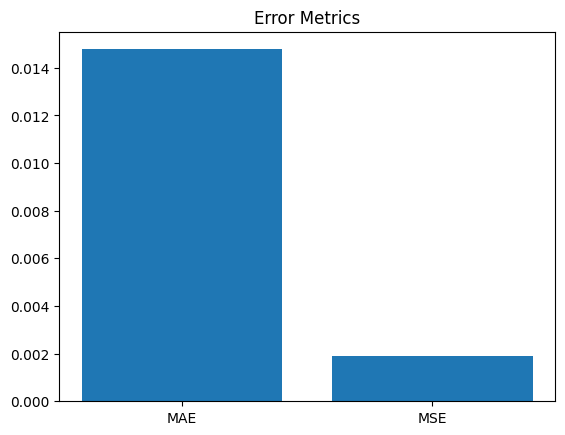

In [12]:
plt.bar(['MAE','MSE'], [mae, mse])
plt.title("Error Metrics")
plt.show()

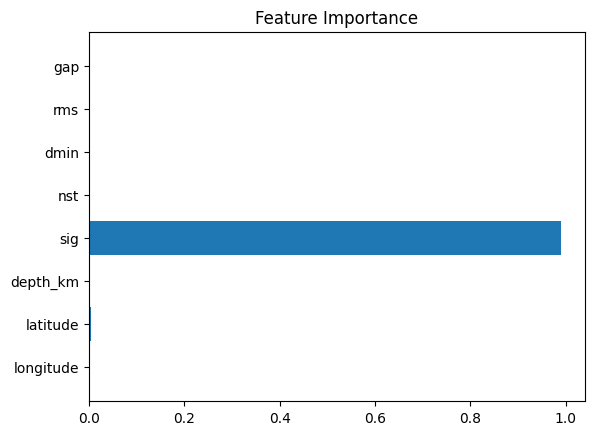

In [13]:
importances = model.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

In [14]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
100%|===================| 4531/4548 [02:47<00:00]        

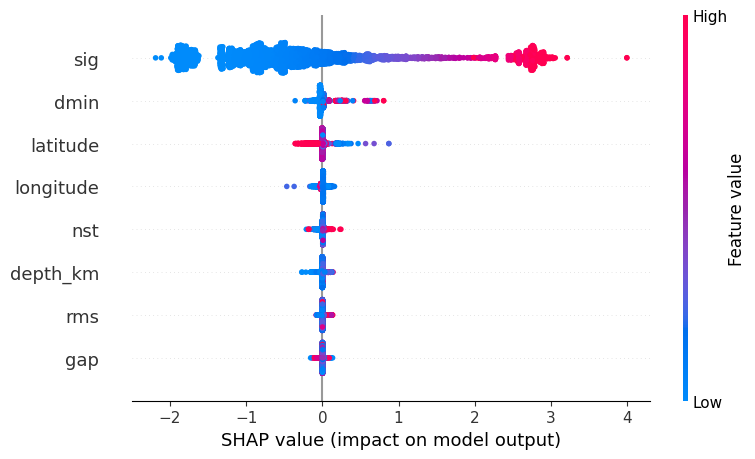

In [15]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [16]:
sample = pd.DataFrame([[78.5, 17.4, 10.0, 500, 20, 0.5, 0.3, 120]],
                      columns=X.columns)

prediction = model.predict(sample)

print("Predicted Magnitude:", prediction)

Predicted Magnitude: [5.2565738]


In [17]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']